# Notebook 04: Optical Flow Preprocessing — Lucas-Kanade
### SIBI Lip Reading — Dataset Gabungan (Angka + Alphabet + Kata)

Notebook ini mengkonversi hasil preprocessing raw lips (`.npy` shape `[30, 96, 96, 3]`)  
menjadi **Lucas-Kanade sparse optical flow** yang sudah diinterpolasi ke dense map.

**Pipeline:**  
`raw_lips/*.npy → Grayscale → Shi-Tomasi corner detect → LK tracking → griddata interpolasi → clip(p2-p98) + z-score → flows_lucaskanade/*.npy`

**Output shape:** `[29, 96, 96, 3]` — 29 flow frames (T-1), 3 channel `[u, v, magnitude]`

In [1]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import os, json, random, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.interpolate import griddata
warnings.filterwarnings('ignore')

print(f'OpenCV : {cv2.__version__}')
print(f'NumPy  : {np.__version__}')
print('scipy.interpolate tersedia ✓')

OpenCV : 4.13.0
NumPy  : 2.4.3
scipy.interpolate tersedia ✓


In [2]:
# ── Cell 2: Config (load dari config.json, sama persis dengan nb 03 & 05) ──
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RAW_LIPS     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
FLOWS_DIR    = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lucaskanade'
STATS_FILE   = FLOWS_DIR / 'norm_stats.json'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'optflow_lk'

FLOWS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES  = cfg['data']['classes']
SPLITS   = cfg['data']['splits']

# ── Parameter Lucas-Kanade ──────────────────────────────────────────────────
# Shi-Tomasi corner detection
FEAT_PARAMS = dict(
    maxCorners   = 200,
    qualityLevel = 0.01,
    minDistance  = 5,
    blockSize    = 5
)
# Pyramid Lucas-Kanade tracking
LK_PARAMS = dict(
    winSize          = (15, 15),
    maxLevel         = 3,
    criteria         = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
    minEigThreshold  = 1e-4    # buang titik di area flat
)
INTERP_METHOD = 'linear'       # griddata method

NUM_CLASSES = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

print(f'Input   : {RAW_LIPS}')
print(f'Output  : {FLOWS_DIR}')
print(f'Classes : {NUM_CLASSES} — {CLASSES}')
print(f'Splits  : {SPLITS}')
print(f'\nLK Parameters:')
print(f'  maxCorners    : {FEAT_PARAMS["maxCorners"]}')
print(f'  qualityLevel  : {FEAT_PARAMS["qualityLevel"]}')
print(f'  minDistance   : {FEAT_PARAMS["minDistance"]}')
print(f'  blockSize     : {FEAT_PARAMS["blockSize"]}')
print(f'  maxLevel      : {LK_PARAMS["maxLevel"]}')
print(f'  griddata      : {INTERP_METHOD}')

Input   : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Output  : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade
Classes : 18 — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Splits  : ['train', 'val', 'test']

LK Parameters:
  maxCorners    : 200
  qualityLevel  : 0.01
  minDistance   : 5
  blockSize     : 5
  maxLevel      : 3
  griddata      : linear


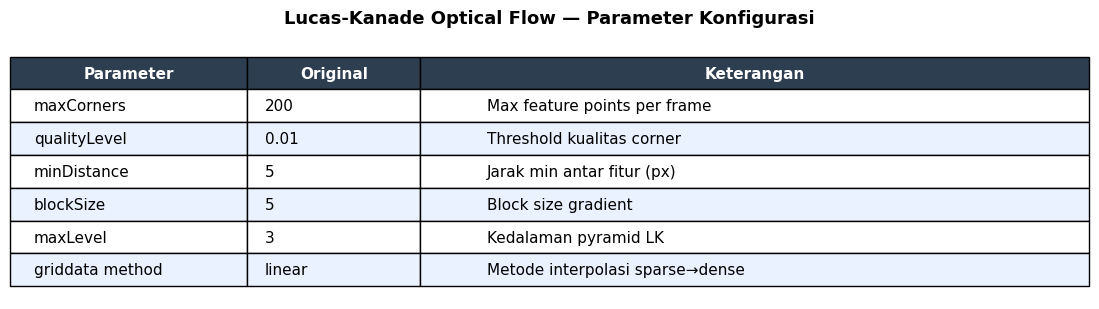

Saved: lk_parameters.png


In [3]:
# ── Cell 3: Tampilkan Parameter Table ──────────────────────────────────────
param_data = {
    'Parameter'   : ['maxCorners', 'qualityLevel', 'minDistance', 'blockSize',
                      'maxLevel', 'griddata method'],
    'Original'    : [200, 0.01, 5, 5, 3, 'linear'],
    'Keterangan'  : [
        'Max feature points per frame',
        'Threshold kualitas corner',
        'Jarak min antar fitur (px)',
        'Block size gradient',
        'Kedalaman pyramid LK',
        'Metode interpolasi sparse→dense'
    ]
}

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
df_p = pd.DataFrame(param_data)
tbl  = ax.table(cellText=df_p.values, colLabels=df_p.columns,
                cellLoc='left', loc='center', colWidths=[0.22, 0.16, 0.62])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
ax.set_title('Lucas-Kanade Optical Flow — Parameter Konfigurasi',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lk_parameters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lk_parameters.png')

---
## Visualisasi Pipeline

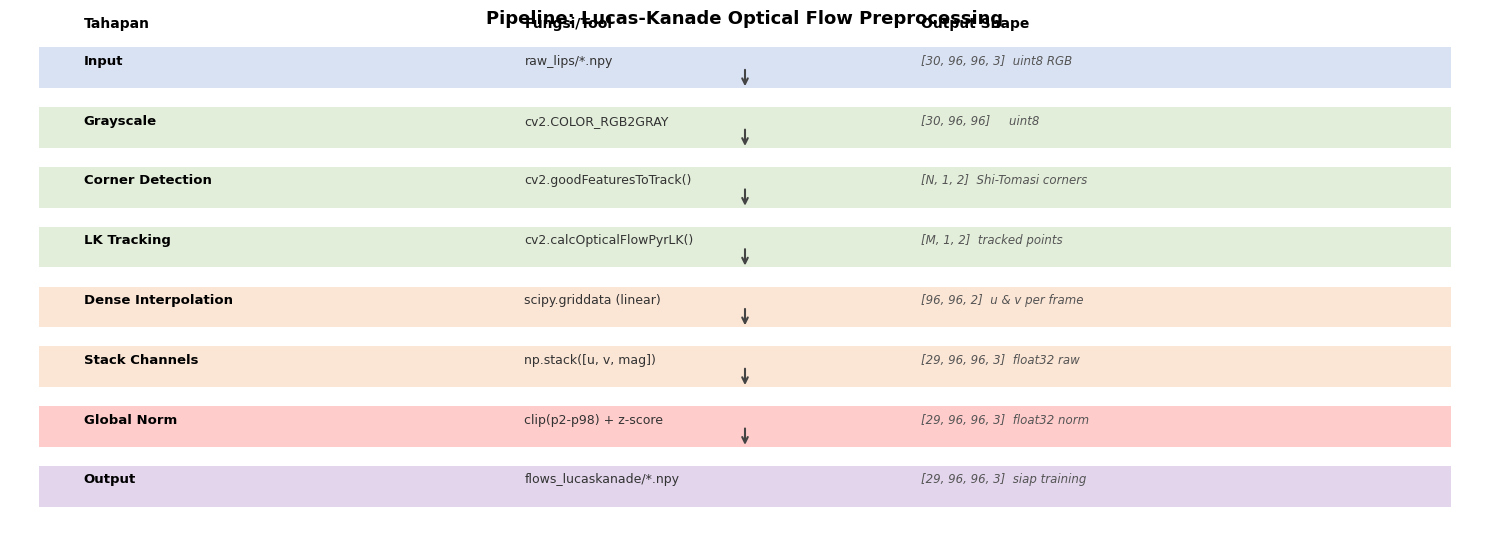

Saved: lk_pipeline.png


In [4]:
# ── Cell 4: Diagram pipeline LK optical flow ───────────────────────────────
pipeline_steps = [
    ('Input',              'raw_lips/*.npy',                  '[30, 96, 96, 3]  uint8 RGB',     '#4472C4'),
    ('Grayscale',          'cv2.COLOR_RGB2GRAY',              '[30, 96, 96]     uint8',         '#70AD47'),
    ('Corner Detection',   'cv2.goodFeaturesToTrack()',       '[N, 1, 2]  Shi-Tomasi corners',  '#70AD47'),
    ('LK Tracking',        'cv2.calcOpticalFlowPyrLK()',      '[M, 1, 2]  tracked points',      '#70AD47'),
    ('Dense Interpolation','scipy.griddata (linear)',         '[96, 96, 2]  u & v per frame',   '#ED7D31'),
    ('Stack Channels',     'np.stack([u, v, mag])',           '[29, 96, 96, 3]  float32 raw',   '#ED7D31'),
    ('Global Norm',        'clip(p2-p98) + z-score',          '[29, 96, 96, 3]  float32 norm',  '#FF0000'),
    ('Output',             'flows_lucaskanade/*.npy',          '[29, 96, 96, 3]  siap training', '#7030A0'),
]

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axis('off')
ax.text(0.05, 1.05, 'Tahapan',       transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.35, 1.05, 'Fungsi/Tool',   transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.62, 1.05, 'Output Shape',  transform=ax.transAxes, fontsize=10, fontweight='bold')
n = len(pipeline_steps)
for i, (step, func, shape, color) in enumerate(pipeline_steps):
    y = 1 - i * (1.0 / n) - 0.02
    ax.add_patch(plt.Rectangle((0.02, y - 0.058), 0.96, 0.085,
                                facecolor=color, alpha=0.2, transform=ax.transAxes, clip_on=False))
    ax.text(0.05, y, step,  transform=ax.transAxes, va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.35, y, func,  transform=ax.transAxes, va='center', fontsize=9,   color='#333')
    ax.text(0.62, y, shape, transform=ax.transAxes, va='center', fontsize=8.5, color='#555', style='italic')
    if i < n - 1:
        ax.annotate('', xy=(0.5, y - 0.06), xytext=(0.5, y - 0.014),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#444', lw=1.5))
ax.set_title('Pipeline: Lucas-Kanade Optical Flow Preprocessing', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lk_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lk_pipeline.png')

---
## Fungsi Optical Flow

In [5]:
# ── Cell 5: Load & grayscale ────────────────────────────────────────────────
def load_gray(npy_path):
    """
    Load lip crop dari raw_lips dan konversi ke grayscale.
    Input : .npy shape [T, H, W, 3] uint8 RGB
    Output: np.array [T, H, W] uint8
    """
    data = np.load(npy_path)   # [T, H, W, 3] uint8
    # raw_lips sudah uint8 BGR dari cv2, konversi ke gray
    return np.array([cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in data])


print('load_gray siap')

load_gray siap


In [6]:
# ── Cell 6: Sparse → Dense interpolation ───────────────────────────────────
def sparse_to_dense(src_pts, flow_vecs, H, W):
    """
    Interpolasi N sparse flow vectors ke dense map menggunakan scipy.griddata.
    src_pts  : (N, 2)  posisi titik fitur (x, y)
    flow_vecs: (N, 2)  vektor displacement (du, dv)
    return   : (H, W, 3) array [u, v, magnitude]
    """
    if len(src_pts) < 4:
        return np.zeros((H, W, 3), dtype=np.float32)

    gy, gx = np.mgrid[0:H, 0:W]
    grid   = np.column_stack([gx.ravel(), gy.ravel()])

    u = griddata(src_pts, flow_vecs[:, 0], grid,
                 method=INTERP_METHOD, fill_value=0.0).reshape(H, W).astype(np.float32)
    v = griddata(src_pts, flow_vecs[:, 1], grid,
                 method=INTERP_METHOD, fill_value=0.0).reshape(H, W).astype(np.float32)
    mag = np.sqrt(u**2 + v**2)

    return np.stack([u, v, mag], axis=-1)


print('sparse_to_dense siap')

sparse_to_dense siap


In [7]:
# ── Cell 7: Lucas-Kanade optical flow ──────────────────────────────────────
def compute_lk_flow(frames):
    """
    Hitung Lucas-Kanade sparse optical flow antar frame berurutan.

    Tahapan per pasangan frame (t, t+1):
      1. Detect Shi-Tomasi corners di frame t
      2. Track corner ke frame t+1 dengan pyramid LK
      3. Filter titik yang berhasil di-track (status == 1)
      4. Hitung displacement (u, v) = posisi_baru - posisi_lama
      5. Interpolasi sparse → dense map (96×96)

    Input : frames [T, H, W] uint8 grayscale
    Output: flow   [T-1, H, W, 3] float32  [u, v, magnitude]
    """
    T, H, W = frames.shape
    if T < 2:
        return None

    flows = []
    for t in range(T - 1):
        p0 = cv2.goodFeaturesToTrack(frames[t], mask=None, **FEAT_PARAMS)

        if p0 is None or len(p0) < 4:
            flows.append(np.zeros((H, W, 3), dtype=np.float32))
            continue

        p1, status, _ = cv2.calcOpticalFlowPyrLK(
            frames[t], frames[t + 1], p0, None, **LK_PARAMS
        )

        mask = status.ravel() == 1
        if mask.sum() < 4:
            flows.append(np.zeros((H, W, 3), dtype=np.float32))
            continue

        old = p0[mask].reshape(-1, 2)
        new = p1[mask].reshape(-1, 2)
        flows.append(sparse_to_dense(old, new - old, H, W))

    return np.array(flows, dtype=np.float32)   # [T-1, H, W, 3]


print('compute_lk_flow siap')

compute_lk_flow siap


---
## Test Pipeline + Visualisasi

In [8]:
# ── Cell 8: Test di 1 video per kategori ───────────────────────────────────
test_samples = {
    'Angka'   : cfg['data']['classes_angka'][0],
    'Alphabet': cfg['data']['classes_alphabet'][0],
    'Kata'    : cfg['data']['classes_kata'][0],
}

for kat, cls in test_samples.items():
    files = sorted((RAW_LIPS / 'train' / cls).glob('*.npy'))
    if not files:
        print(f'[SKIP] {kat}/{cls} — tidak ada file')
        continue
    frames = load_gray(files[0])
    flows  = compute_lk_flow(frames)
    if flows is not None:
        print(f'{kat:8s} | kelas "{cls}" | frames {frames.shape} → flows {flows.shape}')
        for i, ch in enumerate(['u', 'v', 'mag']):
            d = flows[..., i]
            print(f'           {ch}: min={d.min():+.3f}, max={d.max():+.3f}, mean={d.mean():+.4f}')
    else:
        print(f'[GAGAL] {kat}/{cls}')

Angka    | kelas "1" | frames (30, 96, 96) → flows (29, 96, 96, 3)
           u: min=-53.378, max=+98.923, mean=+0.1058
           v: min=-61.751, max=+32.585, mean=+0.1067
           mag: min=+0.000, max=+101.458, mean=+1.9792
Alphabet | kelas "a" | frames (30, 96, 96) → flows (29, 96, 96, 3)
           u: min=-46.687, max=+45.682, mean=+0.0694
           v: min=-34.656, max=+44.992, mean=+0.0200
           mag: min=+0.000, max=+54.989, mean=+1.7812
Kata     | kelas "buku" | frames (30, 96, 96) → flows (29, 96, 96, 3)
           u: min=-48.253, max=+19.875, mean=-0.0288
           v: min=-84.845, max=+27.356, mean=-0.0658
           mag: min=+0.000, max=+84.855, mean=+1.2212


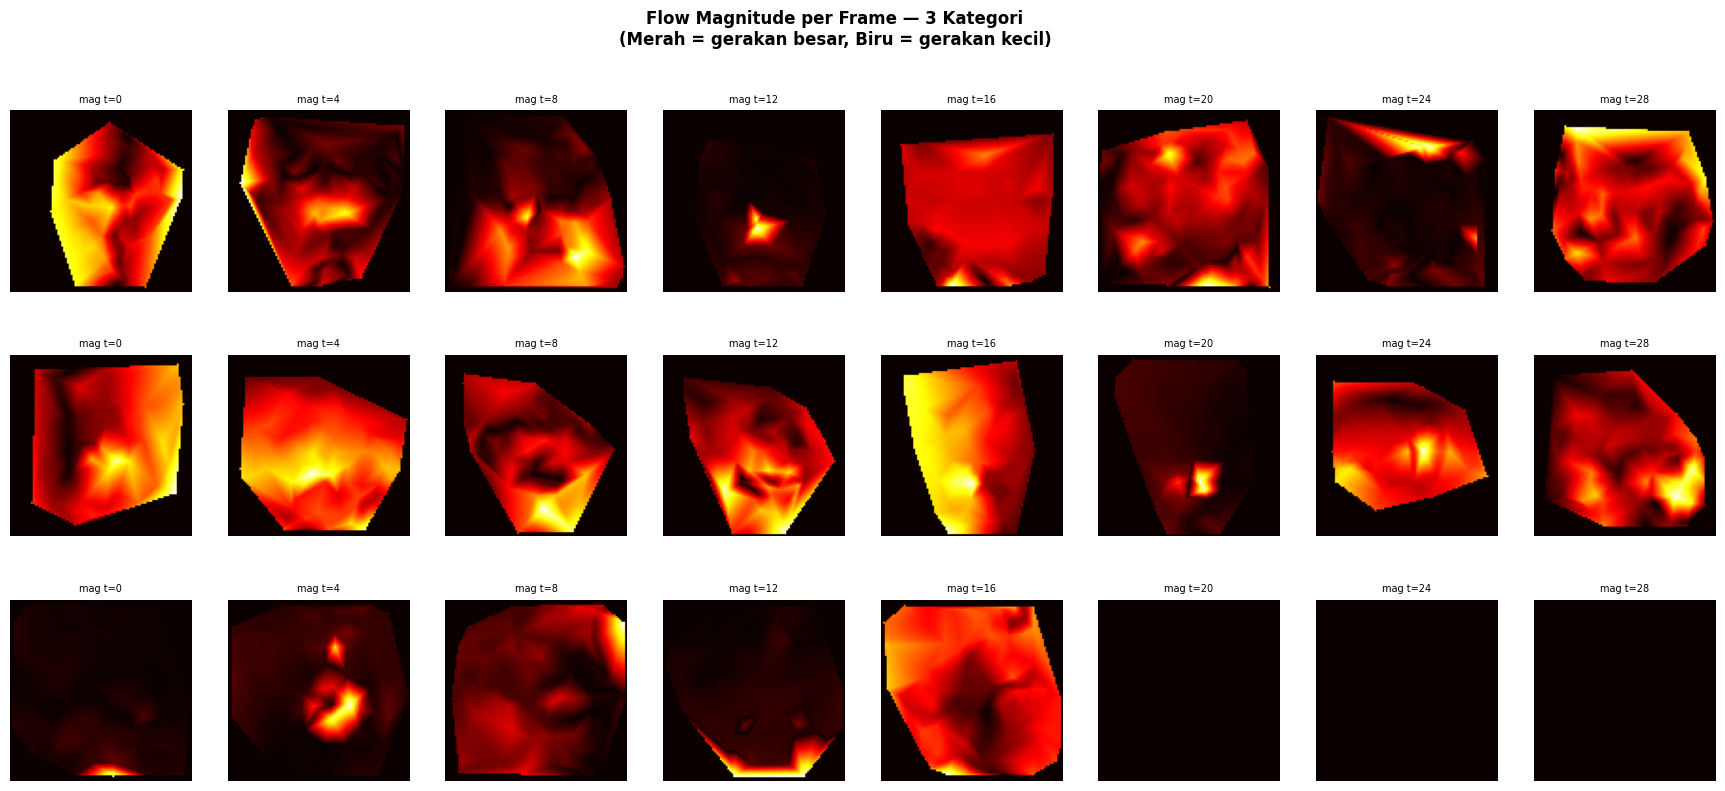

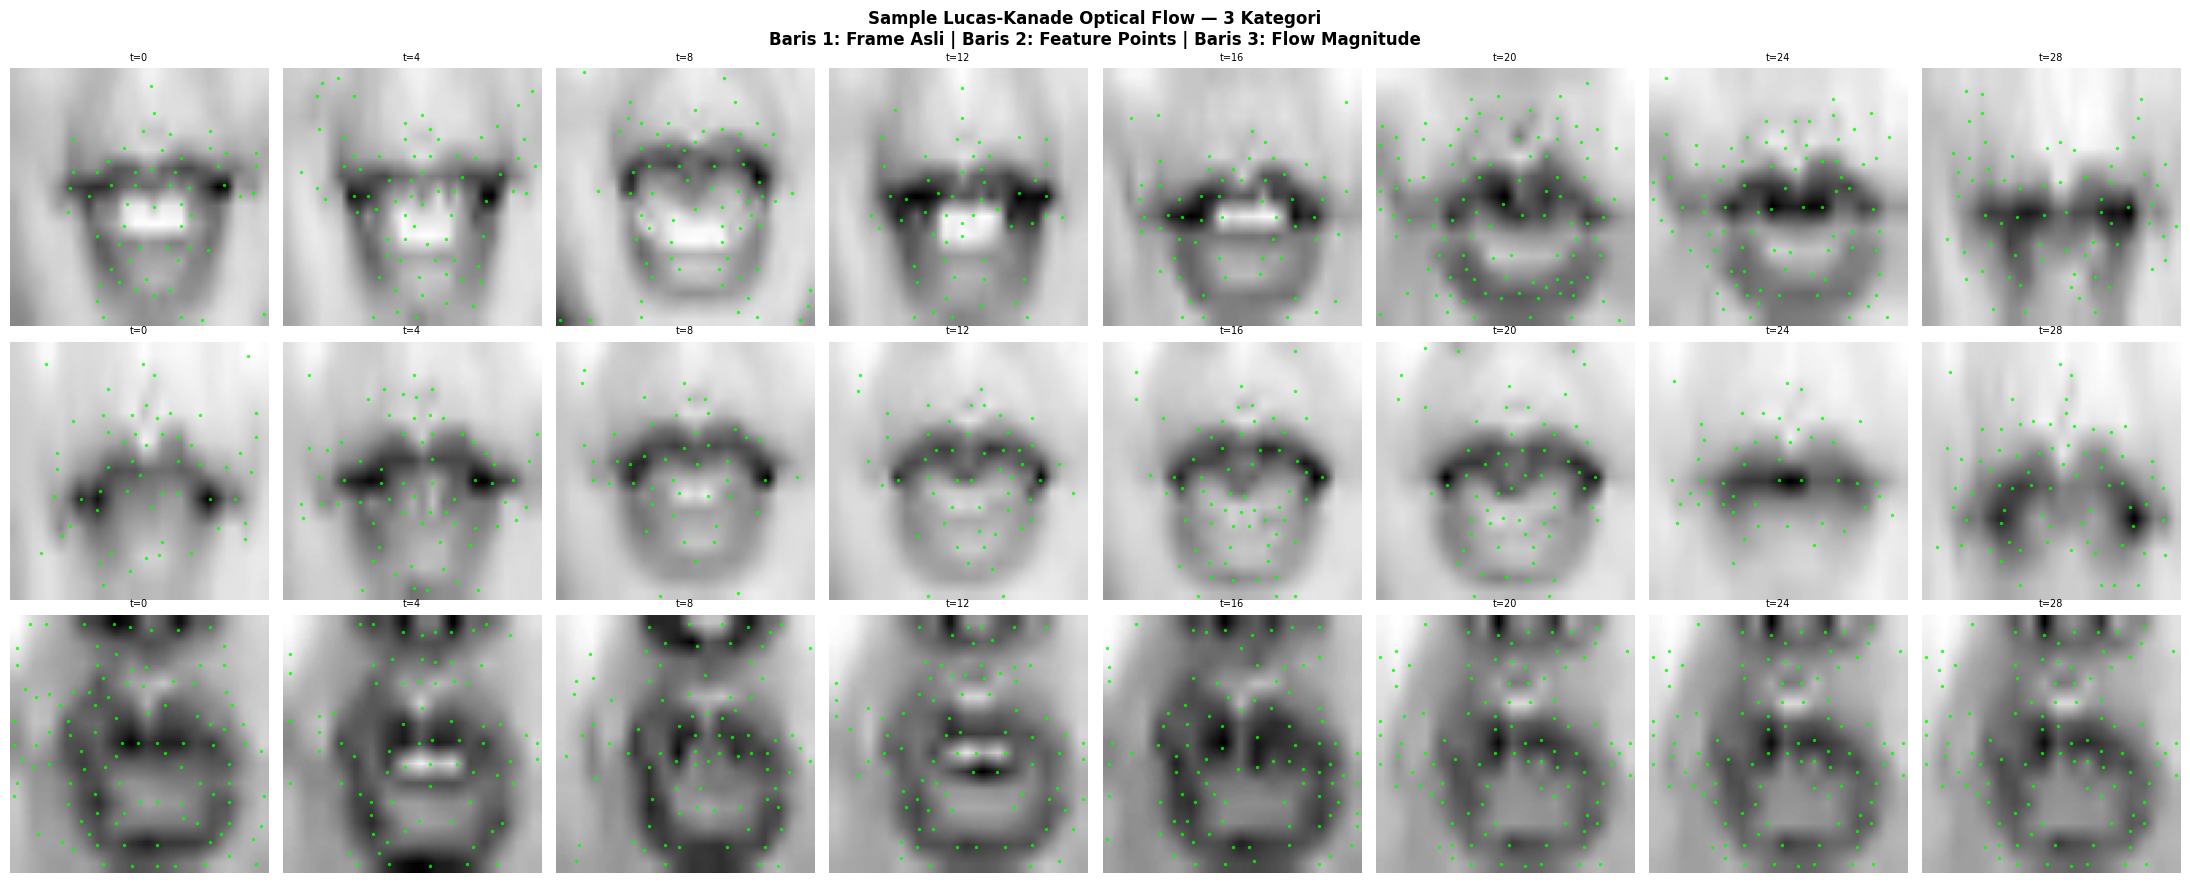

<Figure size 640x480 with 0 Axes>

Saved: test_flow_frames.png, test_flow_magnitude.png


In [9]:
# ── Cell 9: Visualisasi frame + feature points + flow magnitude (3 kategori) ─
fig, axes = plt.subplots(3, 8, figsize=(22, 9))
fig.suptitle('Sample Lucas-Kanade Optical Flow — 3 Kategori\n'
             'Baris 1: Frame Asli | Baris 2: Feature Points | Baris 3: Flow Magnitude',
             fontsize=12, fontweight='bold')

for row, (kat, cls) in enumerate(test_samples.items()):
    files = sorted((RAW_LIPS / 'train' / cls).glob('*.npy'))
    if not files:
        continue
    frames = load_gray(files[0])
    flows  = compute_lk_flow(frames)
    if flows is None:
        continue

    for col, fi in enumerate(np.linspace(0, len(flows)-1, 8, dtype=int)):
        ax = axes[row][col]
        ax.imshow(frames[fi], cmap='gray')

        # overlay feature points
        p0 = cv2.goodFeaturesToTrack(frames[fi], mask=None, **FEAT_PARAMS)
        if p0 is not None:
            pts = p0.reshape(-1, 2)
            ax.scatter(pts[:, 0], pts[:, 1], s=6, c='lime', alpha=0.8, linewidths=0)

        if col == 0:
            ax.set_ylabel(f'{kat}\n"{cls}"', fontsize=8.5, fontweight='bold')
        ax.set_title(f't={fi}', fontsize=7)
        ax.axis('off')

    # tambah row magnitude di bawah setiap kategori — gabungkan di figure terpisah
# buat figure kedua khusus magnitude
fig2, axes2 = plt.subplots(3, 8, figsize=(22, 9))
fig2.suptitle('Flow Magnitude per Frame — 3 Kategori\n'
              '(Merah = gerakan besar, Biru = gerakan kecil)',
              fontsize=12, fontweight='bold')

for row, (kat, cls) in enumerate(test_samples.items()):
    files = sorted((RAW_LIPS / 'train' / cls).glob('*.npy'))
    if not files:
        continue
    frames = load_gray(files[0])
    flows  = compute_lk_flow(frames)
    if flows is None:
        continue

    for col, fi in enumerate(np.linspace(0, len(flows)-1, 8, dtype=int)):
        ax = axes2[row][col]
        im = ax.imshow(flows[fi, :, :, 2], cmap='hot', vmin=0)
        if col == 0:
            ax.set_ylabel(f'{kat}\n"{cls}"', fontsize=8.5, fontweight='bold')
        ax.set_title(f'mag t={fi}', fontsize=7)
        ax.axis('off')

plt.figure(fig.number)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_flow_frames.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(fig2.number)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_flow_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: test_flow_frames.png, test_flow_magnitude.png')

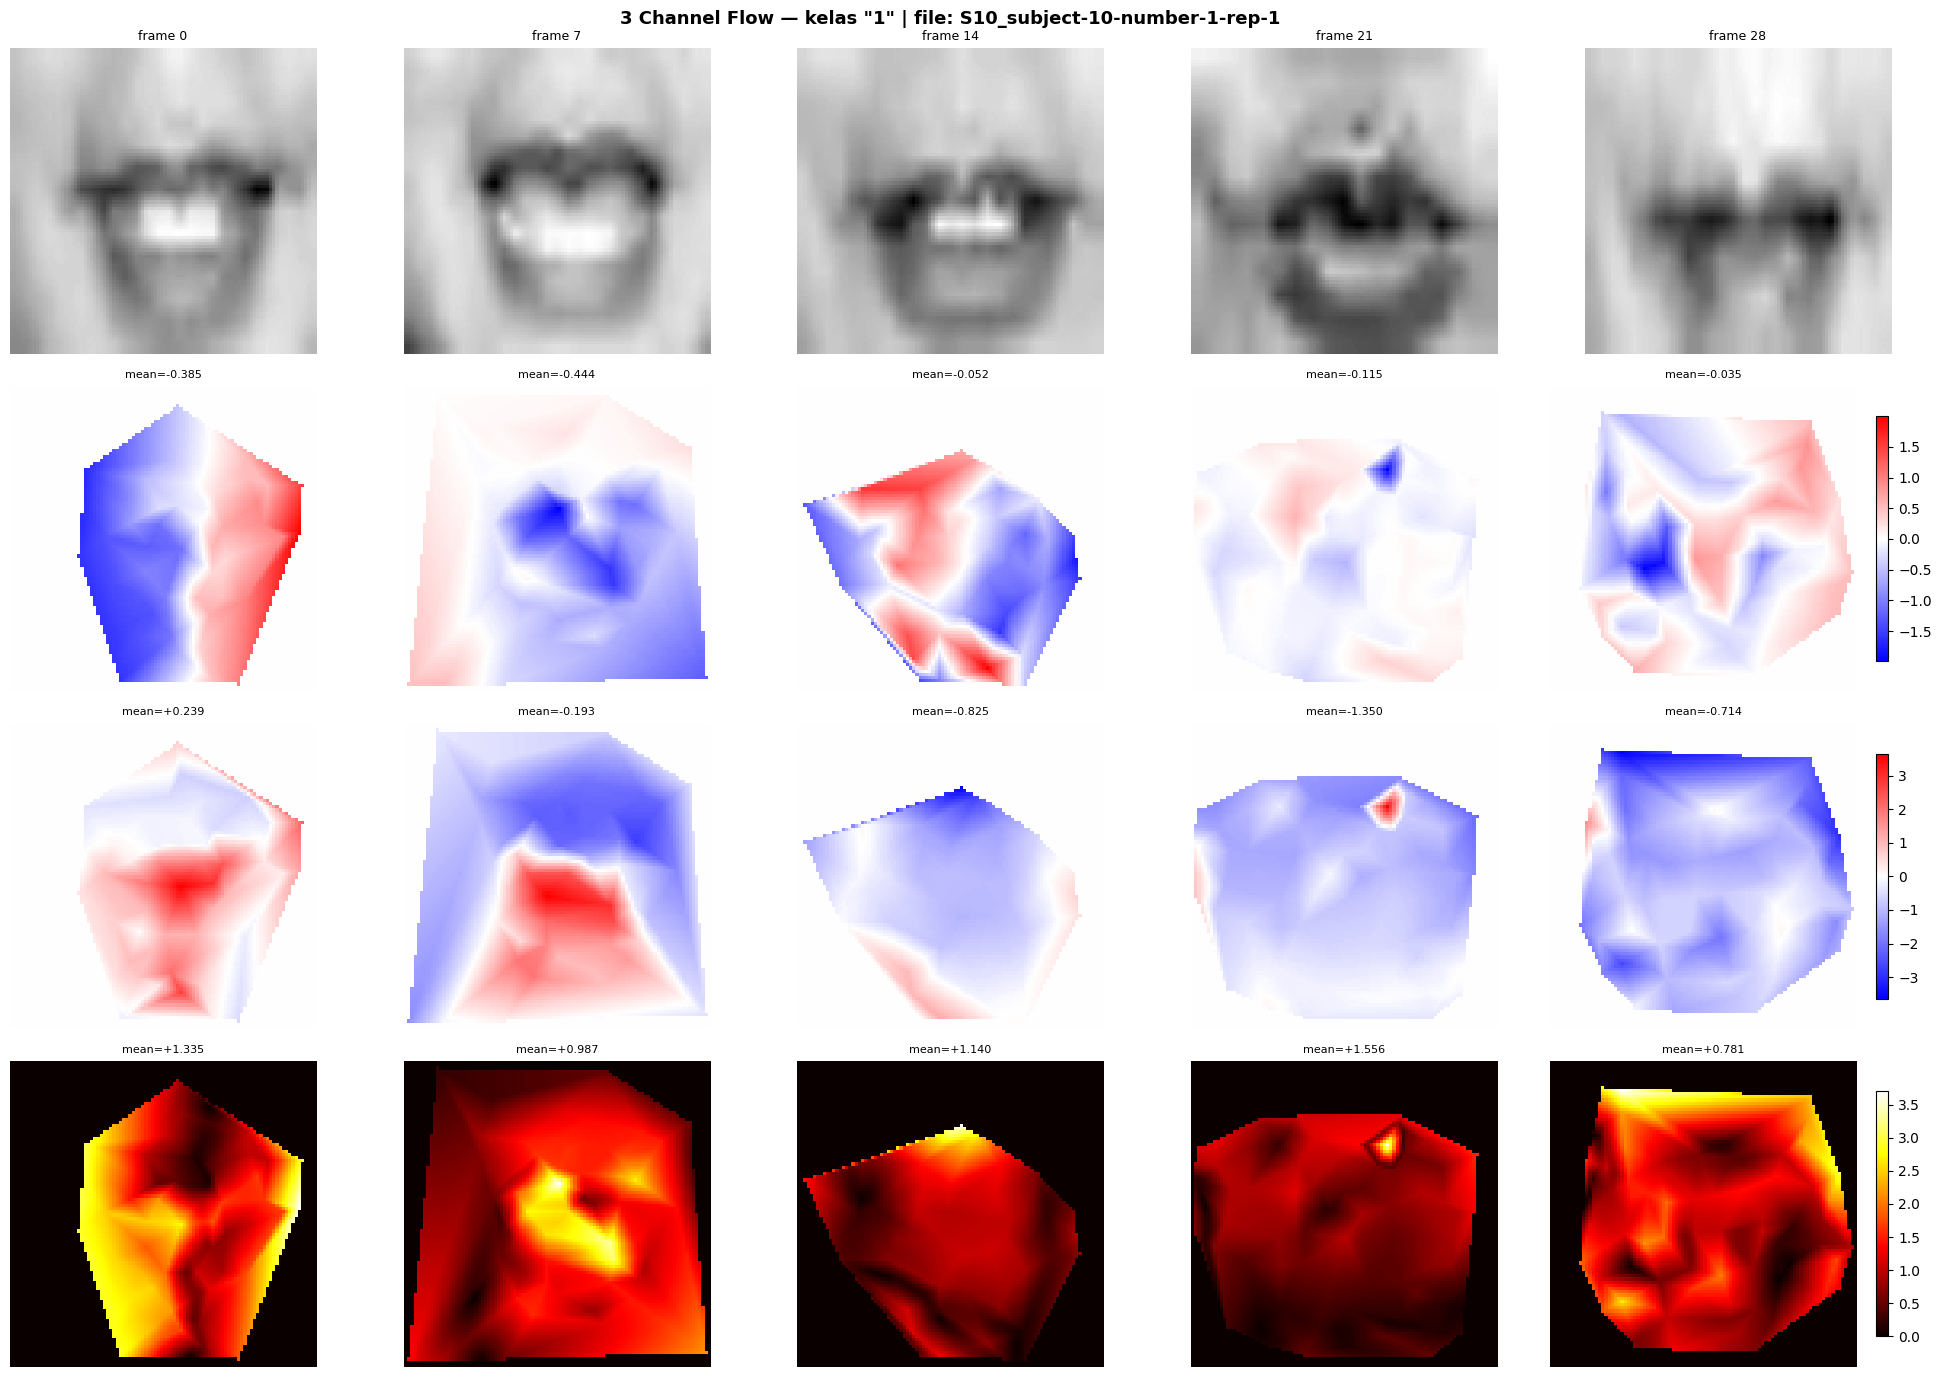

Saved: flow_channels.png


In [10]:
# ── Cell 10: Visualisasi 3 channel flow (u, v, magnitude) dari 1 video ─────
sample_cls  = cfg['data']['classes_angka'][0]
sample_file = sorted((RAW_LIPS / 'train' / sample_cls).glob('*.npy'))[0]
frames_vis  = load_gray(sample_file)
flows_vis   = compute_lk_flow(frames_vis)

n_show     = min(5, len(flows_vis))
show_idx   = np.linspace(0, len(flows_vis)-1, n_show, dtype=int)
ch_labels  = ['u (horizontal)', 'v (vertikal)', 'magnitude']
ch_cmaps   = ['bwr', 'bwr', 'hot']

fig, axes = plt.subplots(4, n_show, figsize=(4*n_show, 14))
fig.suptitle(f'3 Channel Flow — kelas "{sample_cls}" | file: {sample_file.stem}',
             fontsize=13, fontweight='bold')

for col, fi in enumerate(show_idx):
    # row 0: frame asli grayscale
    axes[0, col].imshow(frames_vis[fi], cmap='gray')
    axes[0, col].set_title(f'frame {fi}', fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('Frame Asli', fontsize=10, fontweight='bold')
    axes[0, col].axis('off')

    # row 1-3: channels
    for ch in range(3):
        data  = flows_vis[fi, :, :, ch]
        vabs  = max(abs(data.min()), abs(data.max())) if ch < 2 else None
        vmin  = -vabs if ch < 2 else None
        vmax  =  vabs if ch < 2 else None
        im = axes[ch+1, col].imshow(data, cmap=ch_cmaps[ch], vmin=vmin, vmax=vmax)
        if col == n_show - 1:
            plt.colorbar(im, ax=axes[ch+1, col], shrink=0.8)
        if col == 0:
            axes[ch+1, col].set_ylabel(ch_labels[ch], fontsize=10, fontweight='bold')
        axes[ch+1, col].set_title(f'mean={data.mean():+.3f}', fontsize=8)
        axes[ch+1, col].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'flow_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flow_channels.png')

---
## Hitung Statistik Global (Training Set)

In [11]:
# ── Cell 11: Hitung jumlah file sebelum proses ──────────────────────────────
total = 0
for split in SPLITS:
    sub = 0
    for cls in CLASSES:
        n    = len(list((RAW_LIPS / split / cls).glob('*.npy')))
        sub  += n
        total += n
    print(f'{split:5s}: {sub} file')
print(f'\nTotal   : {total} file')
print(f'Estimasi: ~{total*1.5/60:.0f}–{total*3/60:.0f} menit (LK lebih lambat dari Farneback)')

train: 2520 file
val  : 720 file
test : 360 file

Total   : 3600 file
Estimasi: ~90–180 menit (LK lebih lambat dari Farneback)


In [12]:
# ── Cell 12: PASS 1 — Statistik global dari training set ───────────────────
# PENTING: hanya pakai training set untuk mencegah data leakage!
print('PASS 1: hitung statistik training set...')

train_files = [f for cls in CLASSES
               for f in sorted((RAW_LIPS / 'train' / cls).glob('*.npy'))]
print(f'Total train files: {len(train_files)}')

# Welford online algorithm — stabil numerik, tidak perlu load semua sekaligus
n_px = np.zeros(3, dtype=np.float64)
mean = np.zeros(3, dtype=np.float64)
M2   = np.zeros(3, dtype=np.float64)
failed = []

for f in tqdm(train_files, desc='Computing stats (LK)'):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is None:
            continue
        for ch in range(3):
            for x in flows[..., ch].ravel():
                n_px[ch] += 1
                delta      = x - mean[ch]
                mean[ch]  += delta / n_px[ch]
                M2[ch]    += delta * (x - mean[ch])
    except Exception as e:
        failed.append((f.name, str(e)))

std = np.maximum(np.sqrt(M2 / (n_px - 1)), 1e-6)

print(f'\nStatistik raw ({len(train_files)-len(failed)} file, {len(failed)} gagal):')
for i, ch in enumerate(['u', 'v', 'magnitude']):
    print(f'  {ch:9s}: mean={mean[i]:+.4f}, std={std[i]:.4f}')

PASS 1: hitung statistik training set...
Total train files: 2520


Computing stats (LK):   0%|          | 0/2520 [00:00<?, ?it/s]


Statistik raw (2519 file, 1 gagal):
  u        : mean=-0.0074, std=3.0534
  v        : mean=-0.0885, std=3.8522
  magnitude: mean=+2.4921, std=4.2379


In [13]:
# ── Cell 13: Hitung clip percentile (p2/p98) dari subsample ────────────────
# Clip penting untuk membuang outlier sebelum z-score normalization
print('Hitung percentile clip dari subsample 150 file...')

clip_buf = []
subsample = train_files[:150] if len(train_files) >= 150 else train_files

for f in tqdm(subsample, desc='Percentile sampling', leave=False):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is not None:
            # subsample spasial untuk hemat RAM
            clip_buf.append(flows[::2, ::4, ::4, :])
    except:
        pass

if clip_buf:
    cat      = np.concatenate(clip_buf, axis=0)
    clip_min = np.percentile(cat, 2,  axis=(0, 1, 2))
    clip_max = np.percentile(cat, 98, axis=(0, 1, 2))
else:
    clip_min = mean - 3 * std
    clip_max = mean + 3 * std

stats = {
    'mean'    : mean.tolist(),
    'std'     : std.tolist(),
    'clip_min': clip_min.tolist(),
    'clip_max': clip_max.tolist(),
    'n_files' : len(train_files) - len(failed),
    'channels': ['u', 'v', 'magnitude'],
    'method'  : 'lucas-kanade',
    'feat_params': {str(k): v for k, v in FEAT_PARAMS.items()},
    'interp'  : INTERP_METHOD
}
with open(STATS_FILE, 'w') as f:
    json.dump(stats, f, indent=2)

print(f'\nStatistik + clip range ({len(train_files)-len(failed)} file):')
for i, ch in enumerate(['u', 'v', 'magnitude']):
    print(f'  {ch:9s}: mean={mean[i]:+.4f}, std={std[i]:.4f}, '
          f'clip=[{clip_min[i]:+.3f}, {clip_max[i]:+.3f}]')
print(f'\nStats disimpan: {STATS_FILE}')

Hitung percentile clip dari subsample 150 file...


Percentile sampling:   0%|          | 0/150 [00:00<?, ?it/s]


Statistik + clip range (2519 file):
  u        : mean=-0.0074, std=3.0534, clip=[-6.485, +6.263]
  v        : mean=-0.0885, std=3.8522, clip=[-9.493, +8.637]
  magnitude: mean=+2.4921, std=4.2379, clip=[+0.000, +14.918]

Stats disimpan: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade/norm_stats.json


Mengambil sample distribusi dari 50 file...


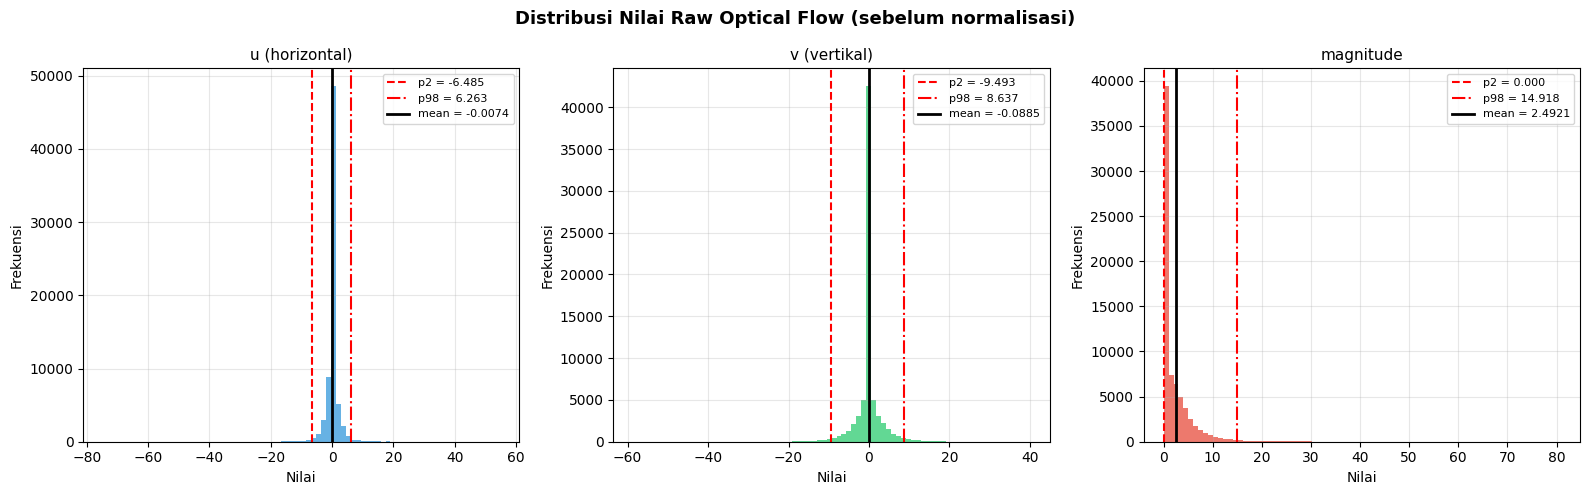

Saved: flow_distribution_raw.png


In [14]:
# ── Cell 14: Visualisasi distribusi raw flow (sebelum normalisasi) ──────────
print('Mengambil sample distribusi dari 50 file...')
dist_buf = []
for f in random.sample(train_files, min(50, len(train_files))):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is not None:
            dist_buf.append(flows[::3, ::8, ::8, :].reshape(-1, 3))
    except:
        pass

if dist_buf:
    dist_data = np.concatenate(dist_buf, axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Distribusi Nilai Raw Optical Flow (sebelum normalisasi)',
                 fontsize=13, fontweight='bold')

    ch_names  = ['u (horizontal)', 'v (vertikal)', 'magnitude']
    ch_colors = ['#3498db', '#2ecc71', '#e74c3c']
    for i, (ch, col) in enumerate(zip(ch_names, ch_colors)):
        d = dist_data[:, i]
        axes[i].hist(d, bins=80, color=col, alpha=0.75, edgecolor='none')
        axes[i].axvline(float(clip_min[i]), color='red', ls='--', lw=1.5, label=f'p2 = {clip_min[i]:.3f}')
        axes[i].axvline(float(clip_max[i]), color='red', ls='-.',  lw=1.5, label=f'p98 = {clip_max[i]:.3f}')
        axes[i].axvline(float(mean[i]),     color='black', ls='-', lw=2,   label=f'mean = {mean[i]:.4f}')
        axes[i].set_title(ch, fontsize=11); axes[i].set_xlabel('Nilai')
        axes[i].set_ylabel('Frekuensi'); axes[i].legend(fontsize=8)
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'flow_distribution_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: flow_distribution_raw.png')

---
## Normalisasi & Batch Processing

In [15]:
# ── Cell 15: Fungsi normalisasi ─────────────────────────────────────────────
# Load stats (bisa dari file kalau kernel restart)
with open(STATS_FILE) as f:
    stats = json.load(f)

G_MEAN = np.array(stats['mean'],     dtype=np.float32)
G_STD  = np.array(stats['std'],      dtype=np.float32)
G_CMIN = np.array(stats['clip_min'], dtype=np.float32)
G_CMAX = np.array(stats['clip_max'], dtype=np.float32)


def normalize(flows):
    """
    Normalisasi flow dengan 2 tahap:
      1. Clip outlier ke rentang [p2, p98] dari training set
      2. Z-score standardization pakai mean & std training set
    Val/Test pakai statistik TRAINING — mencegah data leakage.
    """
    out = flows.copy()
    for ch in range(3):
        out[..., ch] = np.clip(out[..., ch], G_CMIN[ch], G_CMAX[ch])
        out[..., ch] = (out[..., ch] - G_MEAN[ch]) / G_STD[ch]
    return out.astype(np.float32)


print(f'Global stats loaded:')
for i, ch in enumerate(['u', 'v', 'magnitude']):
    print(f'  {ch:9s}: mean={G_MEAN[i]:+.4f}, std={G_STD[i]:.4f}, '
          f'clip=[{G_CMIN[i]:+.3f}, {G_CMAX[i]:+.3f}]')

Global stats loaded:
  u        : mean=-0.0074, std=3.0534, clip=[-6.485, +6.263]
  v        : mean=-0.0885, std=3.8522, clip=[-9.493, +8.637]
  magnitude: mean=+2.4921, std=4.2379, clip=[+0.000, +14.918]


In [16]:
# ── Cell 16: Buat folder output ─────────────────────────────────────────────
for split in SPLITS:
    for cls in CLASSES:
        (FLOWS_DIR / split / cls).mkdir(parents=True, exist_ok=True)

print(f'Folder output siap → {FLOWS_DIR}')

Folder output siap → /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade


In [17]:
# ── Cell 17: PASS 2 — Batch processing semua split ─────────────────────────
import time as _time

ok = 0
fail = 0
fail_log = []

t_start = _time.time()
print(f'PASS 2: proses semua data...\n')

for split in SPLITS:
    print(f'--- {split.upper()} ---')
    for cls in CLASSES:
        files   = sorted((RAW_LIPS / split / cls).glob('*.npy'))
        out_dir = FLOWS_DIR / split / cls

        for f in tqdm(files, desc=f'{split}/{cls}', leave=False):
            out_path = out_dir / f.name
            if out_path.exists():
                ok += 1
                continue
            try:
                flows = compute_lk_flow(load_gray(f))
                if flows is None or len(flows) < 5:
                    fail += 1
                    fail_log.append({'split': split, 'class': cls,
                                     'file': f.name, 'reason': 'flow failed'})
                    continue
                np.save(out_path, normalize(flows))
                ok += 1
            except Exception as e:
                fail += 1
                fail_log.append({'split': split, 'class': cls,
                                 'file': f.name, 'reason': str(e)})

elapsed = (_time.time() - t_start) / 60
print(f'\nSelesai dalam {elapsed:.1f} menit')
print(f'Berhasil: {ok} | Gagal: {fail} | Success rate: {ok/(ok+fail)*100:.1f}%')

PASS 2: proses semua data...

--- TRAIN ---


train/1:   0%|          | 0/140 [00:00<?, ?it/s]

train/2:   0%|          | 0/140 [00:00<?, ?it/s]

train/3:   0%|          | 0/140 [00:00<?, ?it/s]

train/8:   0%|          | 0/140 [00:00<?, ?it/s]

...

test/saya:   0%|          | 0/20 [00:00<?, ?it/s]

test/keliling:   0%|          | 0/20 [00:00<?, ?it/s]

test/kelompok:   0%|          | 0/20 [00:00<?, ?it/s]

test/sekarang:   0%|          | 0/20 [00:00<?, ?it/s]


Selesai dalam 4.4 menit
Berhasil: 3599 | Gagal: 1 | Success rate: 100.0%


---
## Verifikasi Output

In [18]:
# ── Cell 18: Verifikasi jumlah file .npy vs output flow ────────────────────
rows = []
for split in SPLITS:
    for cls in CLASSES:
        n_src  = len(list((RAW_LIPS  / split / cls).glob('*.npy')))
        n_out  = len(list((FLOWS_DIR / split / cls).glob('*.npy')))
        rows.append({'split': split, 'class': cls,
                     'raw_lips': n_src, 'lk_flow': n_out, 'selisih': n_src - n_out})

df_ver = pd.DataFrame(rows)
pivot  = df_ver.pivot_table(index='class', columns='split',
                              values='selisih', aggfunc='sum')

print('Selisih (raw_lips - lk_flow), idealnya 0 semua:')
print(pivot.to_string())
print(f'\nTotal kurang: {df_ver["selisih"].sum()} file')

Selisih (raw_lips - lk_flow), idealnya 0 semua:
split     test  train  val
class                     
1            0      0    0
10           0      0    0
2            0      0    0
3            0      0    0
8            0      0    0
9            0      0    0
a            0      0    0
b            0      1    0
buku         0      0    0
c            0      0    0
d            0      0    0
dia          0      0    0
e            0      0    0
f            0      0    0
keliling     0      0    0
kelompok     0      0    0
saya         0      0    0
sekarang     0      0    0

Total kurang: 1 file


In [19]:
# ── Cell 19: Cek shape output ───────────────────────────────────────────────
expected = (29, 96, 96, 3)   # [T-1, H, W, channels]
err      = 0

for cls in CLASSES:
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    if not files:
        print(f'  kelas {cls:>3}: tidak ada file')
        continue
    arr    = np.load(random.choice(files))
    status = 'OK' if arr.shape == expected else f'ERR {arr.shape}'
    if 'ERR' in status:
        err += 1
    print(f'  kelas {cls:>3}: {arr.shape}  dtype={arr.dtype}  → {status}')

print(f'\nExpected: {expected}')
print(f'Error   : {err} kelas')

  kelas   1: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   2: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   3: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   8: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   9: (29, 96, 96, 3)  dtype=float32  → OK
  kelas  10: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   a: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   b: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   c: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   d: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   e: (29, 96, 96, 3)  dtype=float32  → OK
  kelas   f: (29, 96, 96, 3)  dtype=float32  → OK
  kelas buku: (29, 96, 96, 3)  dtype=float32  → OK
  kelas dia: (29, 96, 96, 3)  dtype=float32  → OK
  kelas saya: (29, 96, 96, 3)  dtype=float32  → OK
  kelas keliling: (29, 96, 96, 3)  dtype=float32  → OK
  kelas kelompok: (29, 96, 96, 3)  dtype=float32  → OK
  kelas sekarang: (29, 96, 96, 3)  dtype=float32  → OK

Expected: (29, 96, 96, 3)
Error   : 0 kelas


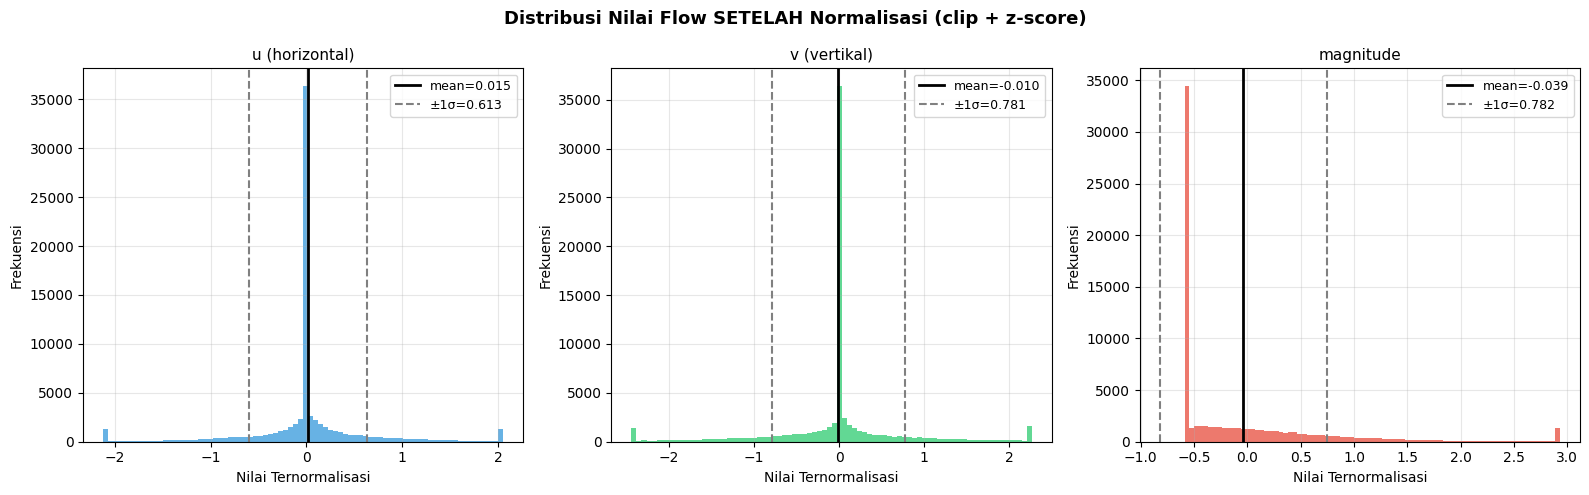

Saved: flow_distribution_normalized.png


In [20]:
# ── Cell 20: Visualisasi distribusi SETELAH normalisasi ────────────────────
norm_buf = []
for cls in CLASSES:
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    for f in random.sample(files, min(3, len(files))):
        d = np.load(f)
        norm_buf.append(d[::3, ::8, ::8, :].reshape(-1, 3))

norm_data = np.concatenate(norm_buf, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Nilai Flow SETELAH Normalisasi (clip + z-score)',
             fontsize=13, fontweight='bold')

ch_names  = ['u (horizontal)', 'v (vertikal)', 'magnitude']
ch_colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (ch, col) in enumerate(zip(ch_names, ch_colors)):
    d = norm_data[:, i]
    axes[i].hist(d, bins=80, color=col, alpha=0.75, edgecolor='none')
    axes[i].axvline(d.mean(), color='black', ls='-', lw=2,
                    label=f'mean={d.mean():.3f}')
    axes[i].axvline(d.mean() + d.std(), color='gray', ls='--', lw=1.5,
                    label=f'±1σ={d.std():.3f}')
    axes[i].axvline(d.mean() - d.std(), color='gray', ls='--', lw=1.5)
    axes[i].set_title(ch, fontsize=11); axes[i].set_xlabel('Nilai Ternormalisasi')
    axes[i].set_ylabel('Frekuensi'); axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'flow_distribution_normalized.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flow_distribution_normalized.png')

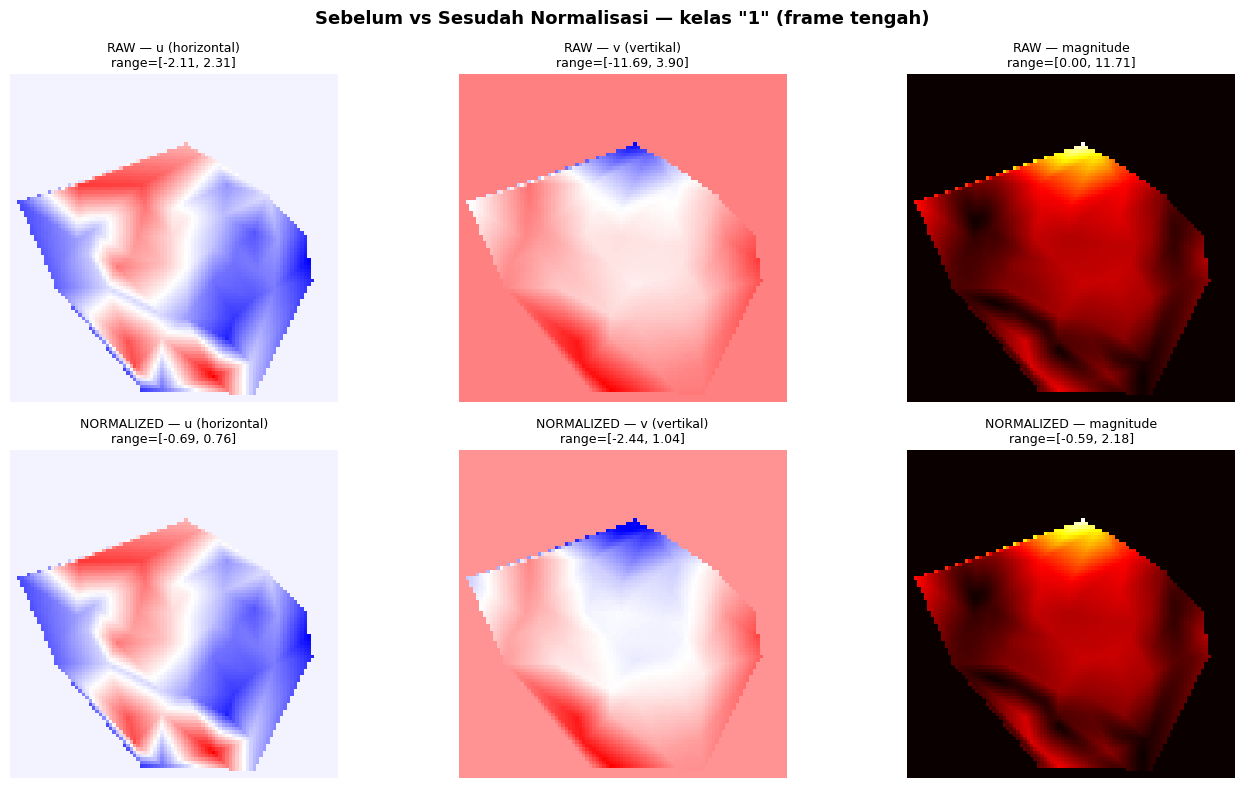

Saved: normalization_comparison.png


In [21]:
# ── Cell 21: Sebelum vs Sesudah normalisasi (side-by-side 3 channel) ───────
sample_cls  = cfg['data']['classes_angka'][0]
sample_file = sorted((RAW_LIPS / 'train' / sample_cls).glob('*.npy'))[0]
raw_flow    = compute_lk_flow(load_gray(sample_file))
norm_flow   = normalize(raw_flow)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle(f'Sebelum vs Sesudah Normalisasi — kelas "{sample_cls}" (frame tengah)',
             fontsize=13, fontweight='bold')

fi = len(raw_flow) // 2
ch_names = ['u (horizontal)', 'v (vertikal)', 'magnitude']
for ch in range(3):
    axes[0, ch].imshow(raw_flow[fi, :, :, ch], cmap='bwr' if ch < 2 else 'hot')
    axes[0, ch].set_title(f'RAW — {ch_names[ch]}\n'
                           f'range=[{raw_flow[fi,:,:,ch].min():.2f}, {raw_flow[fi,:,:,ch].max():.2f}]',
                           fontsize=9)
    axes[0, ch].axis('off')

    axes[1, ch].imshow(norm_flow[fi, :, :, ch], cmap='bwr' if ch < 2 else 'hot')
    axes[1, ch].set_title(f'NORMALIZED — {ch_names[ch]}\n'
                           f'range=[{norm_flow[fi,:,:,ch].min():.2f}, {norm_flow[fi,:,:,ch].max():.2f}]',
                           fontsize=9)
    axes[1, ch].axis('off')

axes[0, 0].set_ylabel('Sebelum (raw)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Sesudah (normalized)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: normalization_comparison.png')

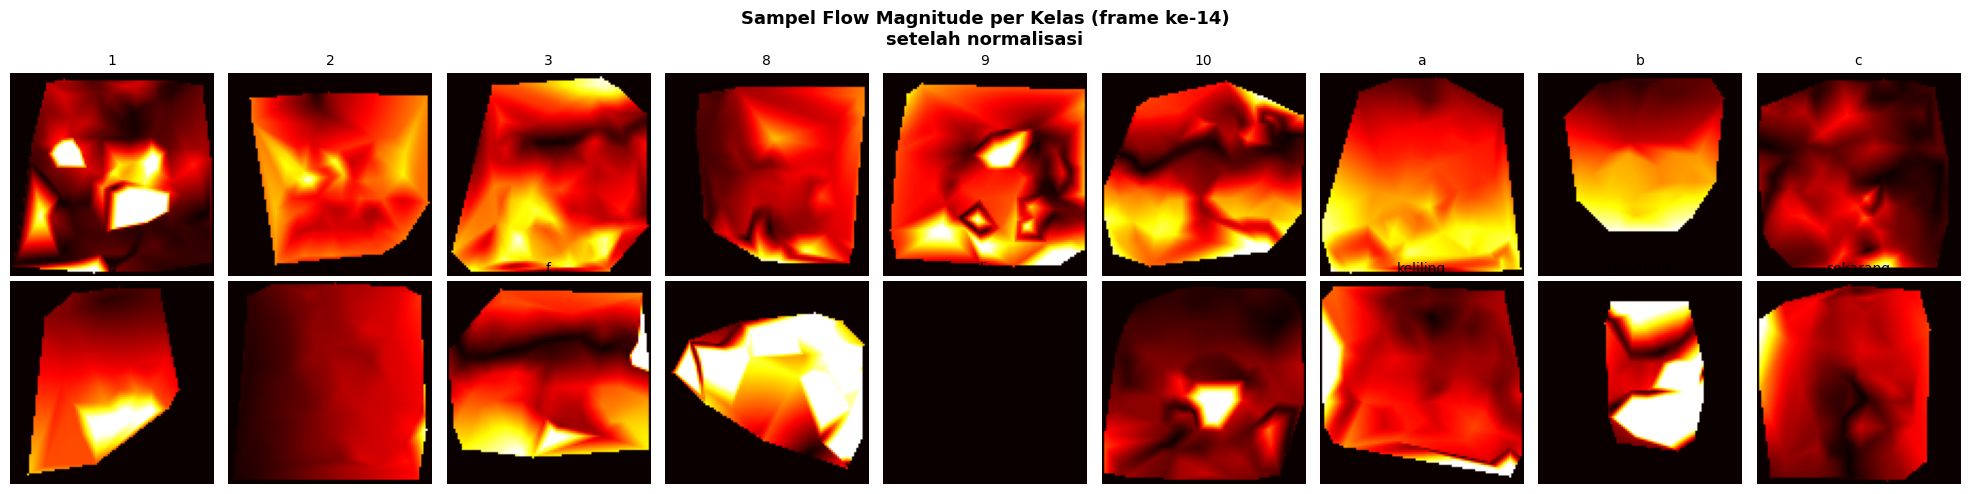

Saved: flow_samples_per_class.png


In [22]:
# ── Cell 22: Visualisasi sampel per kelas (magnitude frame tengah) ──────────
n_cls  = len(CLASSES)
n_cols = 9
n_rows = (n_cls + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.2, n_rows*2.5))
fig.suptitle('Sampel Flow Magnitude per Kelas (frame ke-14)\n'
             'setelah normalisasi', fontsize=13, fontweight='bold')

for idx, cls in enumerate(CLASSES):
    ax    = axes.flatten()[idx]
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    if files:
        flow = np.load(random.choice(files))
        ax.imshow(flow[14, :, :, 2], cmap='hot')
    ax.set_title(cls, fontsize=10)
    ax.axis('off')

for idx in range(n_cls, n_rows * n_cols):
    axes.flatten()[idx].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'flow_samples_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flow_samples_per_class.png')

Menghitung rata-rata feature points per kelas...


Per-class stats:   0%|          | 0/18 [00:00<?, ?it/s]

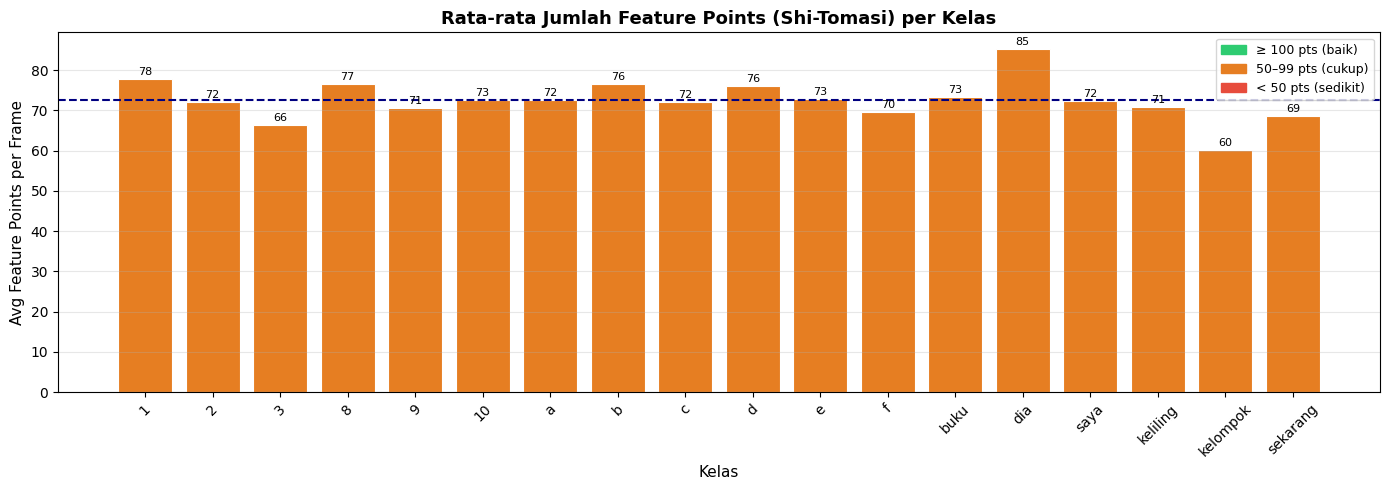

Saved: per_class_feature_count.png


In [23]:
# ── Cell 23: Per-class feature count (rata-rata N titik terdeteksi) ─────────
print('Menghitung rata-rata feature points per kelas...')

class_n_pts = {}
for cls in tqdm(CLASSES, desc='Per-class stats'):
    files  = list((RAW_LIPS / 'train' / cls).glob('*.npy'))
    n_list = []
    for f in random.sample(files, min(10, len(files))):
        try:
            frames_c = load_gray(f)
            for frame in frames_c:
                p = cv2.goodFeaturesToTrack(frame, mask=None, **FEAT_PARAMS)
                n_list.append(len(p) if p is not None else 0)
        except:
            pass
    class_n_pts[cls] = np.mean(n_list) if n_list else 0

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 5))
colors_bar = ['#2ecc71' if v >= 100 else '#e67e22' if v >= 50 else '#e74c3c'
               for v in class_n_pts.values()]
bars = ax.bar(list(class_n_pts.keys()), list(class_n_pts.values()),
              color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, class_n_pts.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{v:.0f}', ha='center', va='bottom', fontsize=8)
ax.axhline(np.mean(list(class_n_pts.values())), color='navy', ls='--', lw=1.5,
           label=f'Avg: {np.mean(list(class_n_pts.values())):.0f} pts')
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Avg Feature Points per Frame', fontsize=11)
ax.set_title('Rata-rata Jumlah Feature Points (Shi-Tomasi) per Kelas',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# legend warna
patches = [
    mpatches.Patch(color='#2ecc71', label='≥ 100 pts (baik)'),
    mpatches.Patch(color='#e67e22', label='50–99 pts (cukup)'),
    mpatches.Patch(color='#e74c3c', label='< 50 pts (sedikit)'),
]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][1:], fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_feature_count.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_feature_count.png')

Menghitung magnitude stats per kelas...


Mag stats:   0%|          | 0/18 [00:00<?, ?it/s]

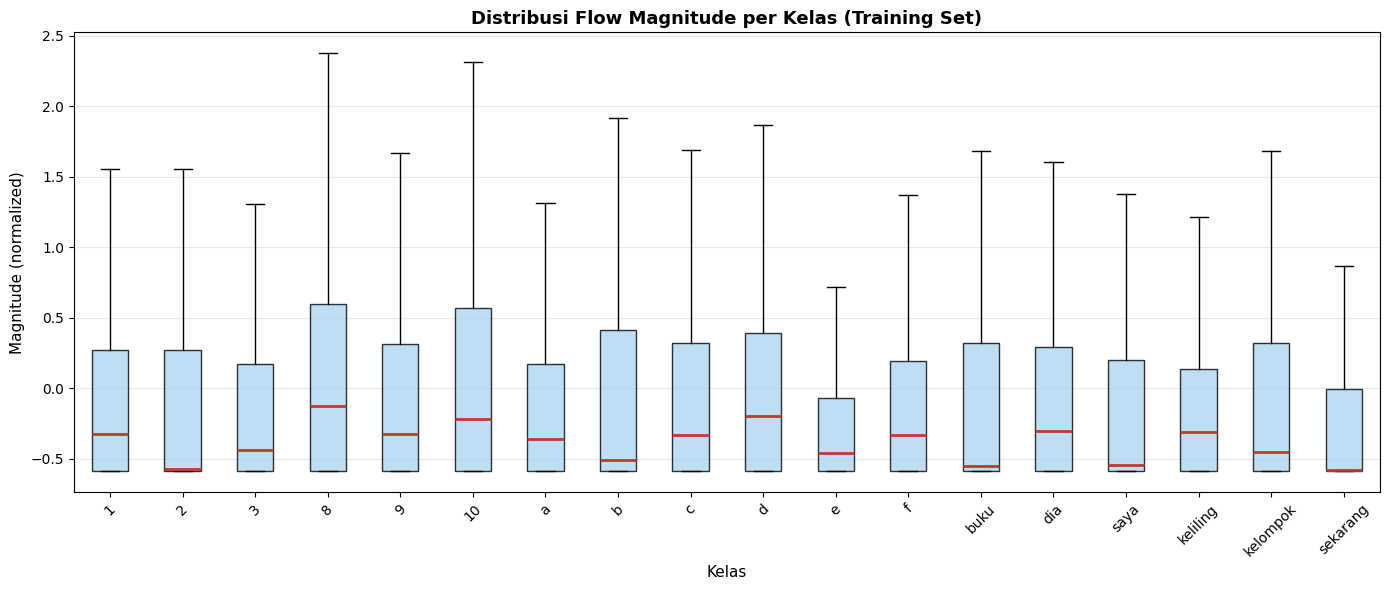

Saved: per_class_magnitude_dist.png


In [24]:
# ── Cell 24: Per-class flow magnitude statistics (box chart) ────────────────
print('Menghitung magnitude stats per kelas...')

mag_data = {}
for cls in tqdm(CLASSES, desc='Mag stats'):
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    mags  = []
    for f in random.sample(files, min(5, len(files))):
        try:
            flow = np.load(f)
            mags.append(flow[:, :, :, 2].ravel())
        except:
            pass
    mag_data[cls] = np.concatenate(mags) if mags else np.array([0.0])

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 6))
bp = ax.boxplot([mag_data[c] for c in CLASSES], labels=CLASSES,
                patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#AED6F1'); patch.set_alpha(0.8)
for med in bp['medians']:
    med.set_color('#C0392B'); med.set_linewidth(2)
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Magnitude (normalized)', fontsize=11)
ax.set_title('Distribusi Flow Magnitude per Kelas (Training Set)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_magnitude_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_magnitude_dist.png')

In [25]:
# ── Cell 25: Simpan fail_log ────────────────────────────────────────────────
if fail_log:
    df_fail = pd.DataFrame(fail_log)
    df_fail.to_csv(RESULTS_DIR / 'fail_log_lk.csv', index=False)
    print(f'Fail log disimpan ({len(fail_log)} file gagal) → fail_log_lk.csv')
    print(df_fail['reason'].value_counts().to_string())
else:
    print('Semua file berhasil diproses ✓')

Fail log disimpan (1 file gagal) → fail_log_lk.csv
reason
QH6013 qhull input error: input is less than 3-dimensional since all points have the same x coordinate   53\n\nWhile executing:  | qhull d Q12 Qbb Qz Qt Qc\nOptions selected for Qhull 2020.2.r 2020/08/31:\n  run-id 1807136957  delaunay  Q12-allow-wide  Qbbound-last  Qz-infinity-point\n  Qtriangulate  Qcoplanar-keep  _pre-merge  _zero-centrum  Qinterior-keep\n  Pgood  _max-width 39  Error-roundoff 9e-14  _one-merge 6.3e-13\n  Visible-distance 1.8e-13  U-max-coplanar 1.8e-13  Width-outside 3.6e-13\n  _wide-facet 1.1e-12  _maxoutside 7.2e-13\n    1


In [26]:
# ── Cell 26: Summary akhir ──────────────────────────────────────────────────
total_npy = sum(
    len(list((FLOWS_DIR / split / cls).glob('*.npy')))
    for split in SPLITS for cls in CLASSES
)

print('=' * 60)
print('  LK OPTICAL FLOW PREPROCESSING SELESAI — Gabungan 18 Kelas')
print('=' * 60)
print(f'  Total file .npy   : {total_npy}')
print(f'  Output shape      : (29, 96, 96, 3)  [T-1, H, W, ch]')
print(f'  Channels          : u, v, magnitude')
print(f'  Normalisasi       : clip(p2-p98) + z-score (training stats)')
print(f'  Output dir        : {FLOWS_DIR}')
print(f'  Gagal             : {fail} file')
print('=' * 60)
print(f'\nFile yang tersimpan:')
all_files = [
    ('norm_stats.json',               'Statistik normalisasi global'),
    ('lk_parameters.png',             'Tabel parameter LK'),
    ('lk_pipeline.png',               'Diagram pipeline'),
    ('test_flow_frames.png',          'Sample frame + feature points'),
    ('test_flow_magnitude.png',       'Sample flow magnitude'),
    ('flow_channels.png',             'Visualisasi 3 channel flow'),
    ('flow_distribution_raw.png',     'Distribusi sebelum normalisasi'),
    ('flow_distribution_normalized.png', 'Distribusi sesudah normalisasi'),
    ('normalization_comparison.png',  'Perbandingan raw vs normalized'),
    ('flow_samples_per_class.png',    'Sampel magnitude per kelas'),
    ('per_class_feature_count.png',   'Feature points per kelas'),
    ('per_class_magnitude_dist.png',  'Distribusi magnitude per kelas'),
]
for fname, desc in all_files:
    path = FLOWS_DIR / fname if fname == 'norm_stats.json' else RESULTS_DIR / fname
    print(f'  [{"✓" if path.exists() else "✗"}] {fname}  —  {desc}')

print('\n→ Lanjut ke Notebook 06: Training Conv-LSTM + Optical Flow')

  LK OPTICAL FLOW PREPROCESSING SELESAI — Gabungan 18 Kelas
  Total file .npy   : 3599
  Output shape      : (29, 96, 96, 3)  [T-1, H, W, ch]
  Channels          : u, v, magnitude
  Normalisasi       : clip(p2-p98) + z-score (training stats)
  Output dir        : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade
  Gagal             : 1 file

File yang tersimpan:
  [✓] norm_stats.json  —  Statistik normalisasi global
  [✓] lk_parameters.png  —  Tabel parameter LK
  [✓] lk_pipeline.png  —  Diagram pipeline
  [✓] test_flow_frames.png  —  Sample frame + feature points
  [✓] test_flow_magnitude.png  —  Sample flow magnitude
  [✓] flow_channels.png  —  Visualisasi 3 channel flow
  [✓] flow_distribution_raw.png  —  Distribusi sebelum normalisasi
  [✓] flow_distribution_normalized.png  —  Distribusi sesudah normalisasi
  [✓] normalization_comparison.png  —  Perbandingan raw vs normalized
  [✓] flow_samples_per_class.png  —  Sampel magn